In [64]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [78]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [66]:
# Postavljanje seed-a
SEED = 3617

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [67]:
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def bind_gpu(data):
    device = get_device()
    if isinstance(data, (list, tuple)):
        return [bind_gpu(data_elem) for data_elem in data]
    else:
        return data.to(device, non_blocking=True)

In [1]:
from pathlib import Path

base_dir = Path("data/tomatoleaf/tomato")

train_dir = base_dir / "train"
val_dir = base_dir / "val"   

print(train_dir)
print(val_dir)

data\tomatoleaf\tomato\train
data\tomatoleaf\tomato\val


In [69]:
# Provera da li je dobro ucitano
print(train_dir.exists())
print(val_dir.exists())

True
True


In [70]:
norm_mean = 0
norm_stddev = 1

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((norm_mean,), (norm_stddev,))
])

In [71]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)

In [77]:
print("Klase:", train_dataset.classes)
print("Broj slika u trening skupu:", len(train_dataset))
print("Broj slika u validacionom skupu:", len(val_dataset))

Klase: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Broj slika u trening skupu: 10000
Broj slika u validacionom skupu: 1000


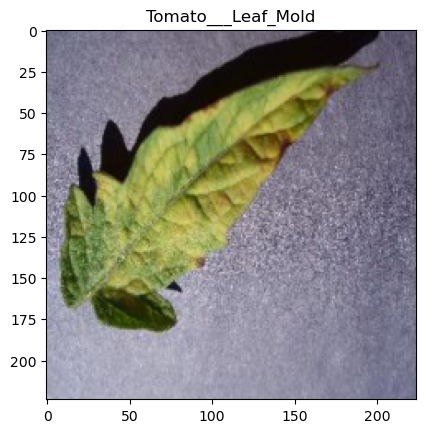

In [73]:
# Prikazivanje slucajno izabrane slike 

ind = np.random.randint(0, 10000, 1)[0]
img, label = train_dataset[ind]

plt.imshow(img.permute(1, 2, 0))
plt.title(train_dataset.classes[label])
plt.show()

In [74]:
train_dataset[0][0].shape  # vidimo da je broj kanala 3 sto nam odgovara, jer su slike u boji; dimenzija slika je 224x224

torch.Size([3, 224, 224])